In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Assuming you have the following datasets
# train_set_x_orig: images for training (shape: (209, 64, 64, 3))
# train_set_y: corresponding labels for training (shape: (209,))
# test_set_x_orig: images for testing (shape: (N, 64, 64, 3))
# test_set_y: corresponding labels for testing (shape: (N,))

# Step 1: Reshape labels to match the image data
train_set_y = train_set_y.reshape(-1)  # Ensures the shape is (209,)
test_set_y = test_set_y.reshape(-1)  # Similarly reshape test labels

# Step 2: Normalize the image data (important for neural networks)
train_set_x_orig = train_set_x_orig / 255.0
test_set_x_orig = test_set_x_orig / 255.0

# Step 3: One-hot encode the labels
train_set_y = to_categorical(train_set_y, num_classes=2)  # Change num_classes based on your dataset
test_set_y = to_categorical(test_set_y, num_classes=2)

# Step 4: Initialize the ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,  # Randomly rotate images in the range of 20 degrees
    width_shift_range=0.2,  # Randomly shift images horizontally by 20%
    height_shift_range=0.2,  # Randomly shift images vertically by 20%
    shear_range=0.2,  # Apply shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Randomly flip images horizontally
    fill_mode='nearest'  # Fill any new pixels with the nearest value
)

# Fit the datagen on the training data
datagen.fit(train_set_x_orig)

# Step 5: Build a neural network model (e.g., CNN)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Assuming 2 classes for classification
])

# Step 6: Compile the model using Adam optimizer
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Train the model with data augmentation
history = model.fit(datagen.flow(train_set_x_orig, train_set_y, batch_size=32),
                    epochs=50,  # Adjust number of epochs as needed
                    validation_data=(test_set_x_orig, test_set_y))

# Step 8: Plotting the results

# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 9: Evaluate the model
score = model.evaluate(test_set_x_orig, test_set_y, verbose=0)
print(f'Test Loss: {score[0]}')
print(f'Test Accuracy: {score[1]}')


NameError: name 'train_set_y' is not defined

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Step 1: Define the learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', 
                                 factor=0.2, patience=5, 
                                 verbose=1, min_lr=1e-6)

# Step 2: Modify model with regularization and additional layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Compile model with Adam optimizer (adjust learning rate)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 3: Train the model with the learning rate scheduler
history = model.fit(datagen.flow(train_set_x_orig, train_set_y, batch_size=32),
                    epochs=50,  # Adjust number of epochs as needed
                    validation_data=(test_set_x_orig, test_set_y),
                    callbacks=[lr_scheduler])  # Add the learning rate scheduler


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.6546 - loss: 1.8861 - val_accuracy: 0.6800 - val_loss: 1.0324 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.7034 - loss: 1.4977 - val_accuracy: 0.6600 - val_loss: 0.9968 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.7291 - loss: 1.2667 - val_accuracy: 0.6600 - val_loss: 0.9914 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.7675 - loss: 1.3151 - val_accuracy: 0.7400 - val_loss: 1.0017 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.8138 - loss: 1.0652 - val_accuracy: 0.6800 - val_loss: 0.9749 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.8588 - loss: 0.8182 - val_accuracy: 0.6800 - val_loss: 1.0062 - learning_rate: 0.0010
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8550 - loss: 0.7575 - val_accuracy: 

In [ ]:
score = model.evaluate(test_set_x_orig, test_set_y, verbose=0)
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")


Test Loss: 2.2005
Test Accuracy: 0.3800


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

# Step 1: Load the VGG16 model pre-trained on ImageNet, excluding the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the layers of the pre-trained model
base_model.trainable = False

# Step 2: Build the new model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Step 3: Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 4: Train the model
history = model.fit(datagen.flow(train_set_x_orig, train_set_y, batch_size=32),
                    epochs=50,  # Adjust number of epochs as needed
                    validation_data=(test_set_x_orig, test_set_y))


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 833ms/step - accuracy: 0.6308 - loss: 0.7944 - val_accuracy: 0.3400 - val_loss: 1.0237
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.6168 - loss: 0.7660 - val_accuracy: 0.3400 - val_loss: 0.8792
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 613ms/step - accuracy: 0.6087 - loss: 0.7086 - val_accuracy: 0.3400 - val_loss: 0.7889
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step - accuracy: 0.6923 - loss: 0.5959 - val_accuracy: 0.4600 - val_loss: 0.7329
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 534ms/step - accuracy: 0.6849 - loss: 0.6056 - val_accuracy: 0.5600 - val_loss: 0.6793
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 687ms/step - accuracy: 0.7209 - loss: 0.5632 - val_accuracy: 0.6400 - val_loss: 0.6366
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 749ms/step - accuracy: 0.7159 - loss: 0.6029 - val_accuracy: 0.7200 - val_loss: 0.6072
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 709ms/step - accuracy: 0.6760 - loss: 0.5826 - val_accuracy: 0.7400 - val_loss:

In [ ]:
# Refine the data augmentation with more variations
datagen = ImageDataGenerator(
    rotation_range=30,  # Rotate images randomly in the range of 30 degrees
    width_shift_range=0.3,  # Shift images horizontally by 30%
    height_shift_range=0.3,  # Shift images vertically by 30%
    shear_range=0.3,  # Apply shear transformations
    zoom_range=0.3,  # Random zoom
    horizontal_flip=True,  # Randomly flip images horizontally
    brightness_range=[0.2, 1.0],  # Adjust brightness of images
    channel_shift_range=50.0,  # Randomly shift the color channels
    fill_mode='nearest'  # Fill any new pixels with the nearest value
)

# Fit the datagen on the training data
datagen.fit(train_set_x_orig)


In [ ]:
# Add batch normalization to the model architecture for faster training
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Compile and fit the model as before
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(datagen.flow(train_set_x_orig, train_set_y, batch_size=32),
                    epochs=50,  # Adjust number of epochs as needed
                    validation_data=(test_set_x_orig, test_set_y))


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.6483 - loss: 0.6927 - val_accuracy: 0.6600 - val_loss: 0.6894
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.6702 - loss: 0.6905 - val_accuracy: 0.5600 - val_loss: 0.6908
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.6836 - loss: 0.6882 - val_accuracy: 0.5200 - val_loss: 0.6921
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6655 - loss: 0.6867 - val_accuracy: 0.5200 - val_loss: 0.6933
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.6844 - loss: 0.6839 - val_accuracy: 0.4400 - val_loss: 0.6945
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.6531 - loss: 0.6838 - val_accuracy: 0.4000 - val_loss: 0.6956
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.6210 - loss: 0.6845 - val_accuracy: 0.4000 - val_loss: 0.6965
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.6634 - loss: 0.6798 - val_accuracy: 0.3600 - val_loss:

Test Loss: 2.128770351409912
Test Accuracy: 0.6600000262260437


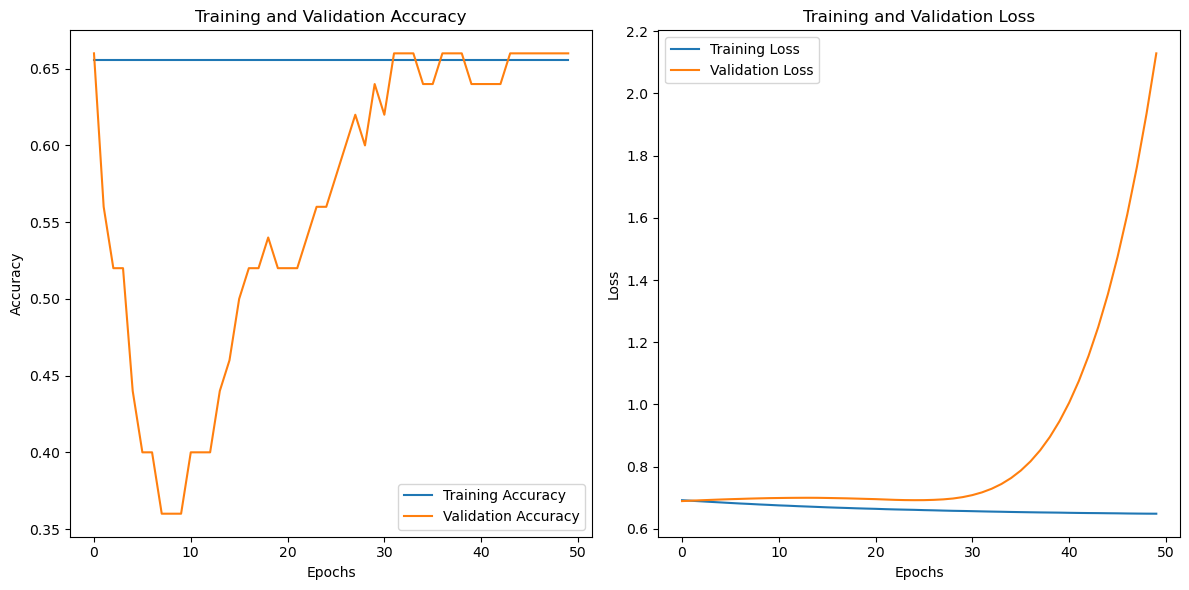

In [ ]:
# Evaluate the model on the test data
score = model.evaluate(test_set_x_orig, test_set_y, verbose=0)
print(f'Test Loss: {score[0]}')
print(f'Test Accuracy: {score[1]}')

# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


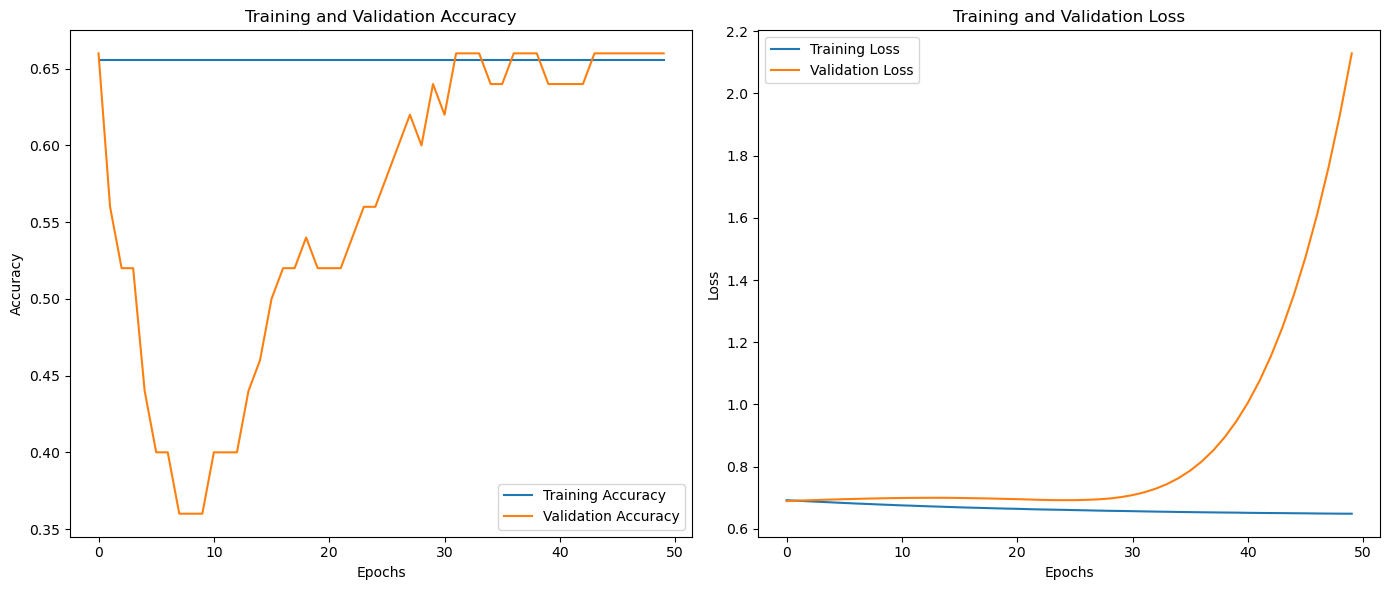

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Get predictions
predictions = model.predict(test_set_x_orig)
predicted_classes = predictions.argmax(axis=-1)
true_classes = test_set_y.argmax(axis=-1)

# Generate classification report
report = classification_report(true_classes, predicted_classes, target_names=['Class 0', 'Class 1'])
print(report)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
              precision    recall  f1-score   support

     Class 0       0.50      0.35      0.41        17
     Class 1       0.71      0.82      0.76        33

    accuracy                           0.66        50
   macro avg       0.61      0.59      0.59        50
weighted avg       0.64      0.66      0.64        50

